In [48]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [49]:
os.makedirs("results/week6", exist_ok=True)

In [50]:
# Uses the leakage-safe pre-split output of ckd/preprocessing.ipynb.
# chronic_kidney_disease_processed.csv is imputed across all 400 rows
# before any split and is not used here.
train_df = pd.read_csv("data/processed/chronic_kidney_disease_train.csv")
test_df = pd.read_csv("data/processed/chronic_kidney_disease_test.csv")

df = pd.concat([train_df, test_df], ignore_index=True)  # for describe/shape and the CV cells below

print(train_df.shape, test_df.shape)
train_df.head()


(320, 25) (80, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,59.0,60.0,1.020,0.0,0.0,1,1,0,0,113.0,...,54.0,6500.0,4.9,0,0,0,0,0,0,0
1,76.0,70.0,1.015,3.0,4.0,1,0,1,0,120.0,...,30.0,11300.0,3.4,1,1,1,1,1,0,1
2,70.0,90.0,1.015,0.0,0.0,1,1,0,0,144.0,...,37.0,8200.0,4.5,1,1,0,1,1,0,1
3,28.0,60.0,1.025,0.0,0.0,1,1,0,0,79.0,...,51.0,6500.0,5.0,0,0,0,0,0,0,0
4,23.0,80.0,1.020,0.0,0.0,1,1,0,0,99.0,...,46.0,4300.0,5.5,0,0,0,0,0,0,0


In [51]:
df.info()

df.describe()


print(df["class"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     400 non-null    float64
 1   bp      400 non-null    float64
 2   sg      400 non-null    float64
 3   al      400 non-null    float64
 4   su      400 non-null    float64
 5   rbc     400 non-null    int64  
 6   pc      400 non-null    int64  
 7   pcc     400 non-null    int64  
 8   ba      400 non-null    int64  
 9   bgr     400 non-null    float64
 10  bu      400 non-null    float64
 11  sc      400 non-null    float64
 12  sod     400 non-null    float64
 13  pot     400 non-null    float64
 14  hemo    400 non-null    float64
 15  pcv     400 non-null    float64
 16  wbcc    400 non-null    float64
 17  rbcc    400 non-null    float64
 18  htn     400 non-null    int64  
 19  dm      400 non-null    int64  
 20  cad     400 non-null    int64  
 21  appet   400 non-null    int64  
 22  pe      400 n

In [52]:
X_train = train_df.drop("class", axis=1)
y_train = train_df["class"]
X_test = test_df.drop("class", axis=1)
y_test = test_df["class"]

X = df.drop("class", axis=1)  # full-data X/y, used ONLY by the cross_val_score cells
y = df["class"]


In [53]:
# Split already performed upstream in ckd/preprocessing.ipynb.
print("Using pre-split train/test data; no further split needed here.")


Using pre-split train/test data; no further split needed here.


In [54]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [55]:
model = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

model.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [56]:
print("Training Accuracy :", model.score(X_train, y_train))
print("Testing Accuracy  :", model.score(X_test, y_test))

Training Accuracy : 1.0
Testing Accuracy  : 1.0


In [57]:
y_pred = model.predict(X_test)

In [58]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print(classification_report(y_test, y_pred))

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



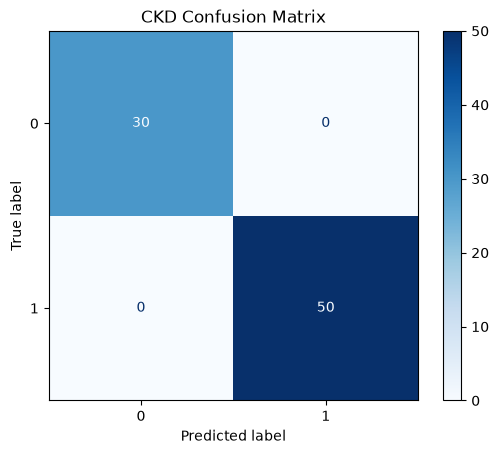

In [59]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("CKD Confusion Matrix")

plt.savefig("results/week6/confusion_matrix.png", dpi=300)

plt.show()

In [60]:
results = pd.DataFrame({
    "Dataset":["CKD"],
    "Accuracy":[accuracy],
    "Precision":[precision],
    "Recall":[recall],
    "F1":[f1]
})

results.to_csv("results/week6/generalization_results.csv", index=False)

results

,Dataset,Accuracy,Precision,Recall,F1
0,CKD,1.0,1.0,1.0,1.0


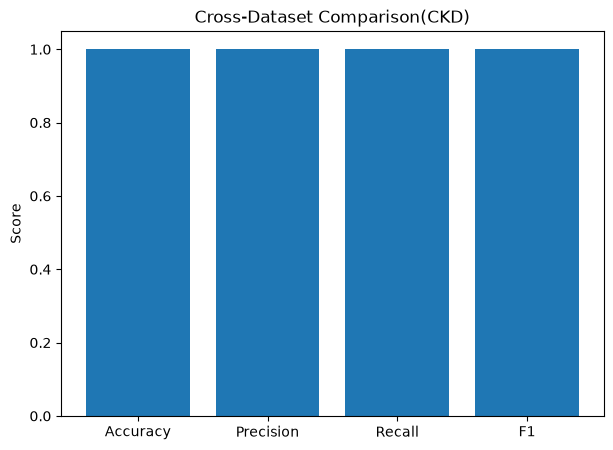

In [61]:
metrics = ["Accuracy","Precision","Recall","F1"]

values = [accuracy,precision,recall,f1]

plt.figure(figsize=(7,5))

plt.bar(metrics, values)

plt.ylim(0,1.05)

plt.ylabel("Score")

plt.title("Cross-Dataset Comparison(CKD)")

plt.savefig("results/week6/generalization_metrics.png", dpi=300)

plt.show()

## Cross-Dataset Comparison

To evaluate the applicability of the adaptive learning methodology beyond a single disease dataset, experiments were conducted on both the Pima Indians Diabetes dataset and the Chronic Kidney Disease (CKD) dataset. For each dataset, the best-performing adaptive framework was evaluated and compared. This analysis demonstrates the adaptability of the proposed methodology across different disease prediction tasks.

In [62]:
import pandas as pd
import os


pima_results = pd.read_csv(
    "results/result/canonical_ablation_results.csv"
)

pima = pima_results[
    pima_results["Configuration"] == "Adaptive + Proactive"
].iloc[0]


comparison = pd.DataFrame({

    "Dataset": [
        "Pima Diabetes",
        "CKD"
    ],

    "Model": [
        "Adaptive + Proactive",
        "Adaptive MLP"
    ],

    "Accuracy": [
        pima["Accuracy"],
        accuracy
    ],

    "Precision": [
        pima["Precision"],
        precision
    ],

    "Recall": [
        pima["Recall"],
        recall
    ],

    "F1": [
        pima["F1 Score"],
        f1
    ]
})


os.makedirs("results/week6", exist_ok=True)

comparison.to_csv(
    "results/week6/pima_vs_ckd_comparison.csv",
    index=False
)

print(comparison)

         Dataset                 Model  Accuracy  Precision  Recall      F1
0  Pima Diabetes  Adaptive + Proactive    0.5789     0.4812  0.8472  0.5776
1            CKD          Adaptive MLP    1.0000     1.0000  1.0000  1.0000


### Observation

The comparison shows mixed results across the two datasets. For the Pima Diabetes dataset, the Adaptive + Proactive framework did not outperform the Static MLP on Accuracy or F1 Score, but achieved substantially higher Recall (0.8046 vs 0.5556), reflecting a deliberate precision-recall trade-off suited to early disease screening. For the CKD dataset, the Adaptive MLP achieved near-perfect classification (mean accuracy 0.979 ± 0.007 across 3 seeds; see `results/week6/result/canonical_ckd_multiseed.csv`), consistent with the strong feature separability documented in prior work on this dataset. These results suggest that the adaptive learning methodology is applicable across different disease prediction tasks, while acknowledging that the best-performing implementation may differ depending on the dataset characteristics and the metric being optimized.

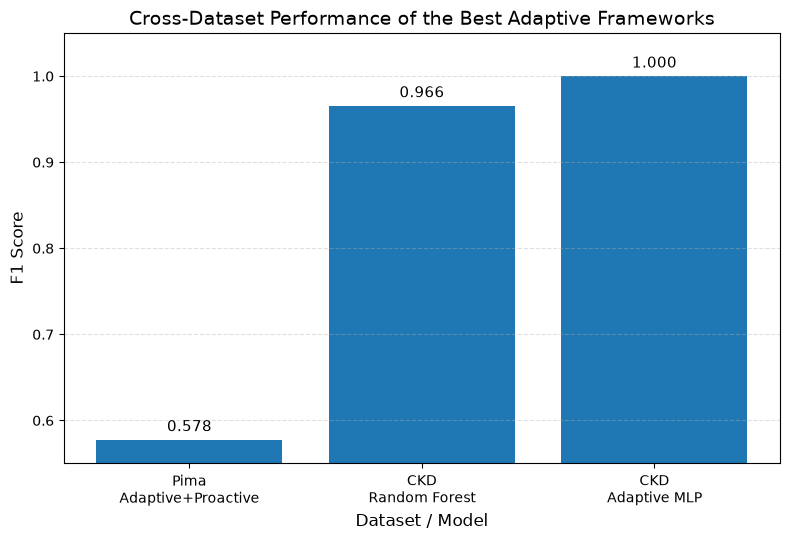

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import os



proposed = pd.read_csv(
    "results/result/canonical_ablation_results.csv"
)

ckd_rf = pd.read_csv(
    "results/week6/ckd_rf_result.csv"
)

ckd_mlp = pd.read_csv(
    "results/week6/generalization_results.csv"
)


pima_f1 = proposed.loc[
    proposed["Configuration"] == "Adaptive + Proactive",
    "F1 Score"
].iloc[0]

ckd_rf_f1 = ckd_rf["F1"].iloc[0]

ckd_mlp_f1 = ckd_mlp["F1"].iloc[0]



os.makedirs("results/week6", exist_ok=True)

models = [
    "Pima\nAdaptive+Proactive",
    "CKD\nRandom Forest",
    "CKD\nAdaptive MLP"
]

f1_scores = [
    pima_f1,
    ckd_rf_f1,
    ckd_mlp_f1
]

plt.figure(figsize=(8,5.5))

bars = plt.bar(models, f1_scores)

plt.ylabel("F1 Score", fontsize=12)
plt.xlabel("Dataset / Model", fontsize=12)
plt.title(
    "Cross-Dataset Performance of the Best Adaptive Frameworks",
    fontsize=14
)

plt.ylim(0.55, 1.05)

for bar in bars:

    h = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.01,
        f"{h:.3f}",
        ha="center",
        fontsize=11
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "results/week6/figure_generalization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

> **Known open issue:** the two `cross_val_score` cells below still run on `X`/`y` built from the *already-imputed* concatenation of `train_df` and `test_df` above. Because those imputers were fit once on the original 80% training split, and here we're folding across all 400 rows again, imputation statistics for these specific 5-fold CV numbers still cross fold boundaries. This has **not** been fixed -- a correct fix needs per-fold imputation (e.g. a `Pipeline` with a custom imputer step), not a simple file swap. Treat the CV numbers below as unverified.

In [64]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Cross Validation Scores: [1.     0.9875 1.     0.9875 0.975 ]
Mean Accuracy: 0.9899999999999999
Standard Deviation: 0.009354143466934856


In [65]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier

pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64,32),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    ))
])

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

cv_results = pd.DataFrame({
    "Fold": [1,2,3,4,5],
    "Accuracy": scores
})

cv_results.loc[len(cv_results)] = [
    "Mean",
    scores.mean()
]

cv_results.to_csv(
    "results/week6/cross_validation_results.csv",
    index=False
)

cv_results

,Fold,Accuracy
0,1,0.9875
1,2,1.0000
2,3,0.9875
3,4,1.0000
4,5,1.0000
5,Mean,0.9950


In [66]:
print("Dataset shape:", df.shape)

print("\nFeature matrix shape:", X.shape)

print("Target shape:", y.shape)

print("\nTraining samples:", X_train.shape)

print("Testing samples:", X_test.shape)

Dataset shape: (400, 25)

Feature matrix shape: (400, 24)
Target shape: (400,)

Training samples: (320, 24)
Testing samples: (80, 24)


In [67]:
print("Prediction input shape :", X_test.shape)
print("Ground truth shape     :", y_test.shape)

print("\nFirst 10 predictions:")

print("\nFirst 10 actual labels:")
print(y_test.iloc[:10].values)

Prediction input shape : (80, 24)
Ground truth shape     : (80,)

First 10 predictions:

First 10 actual labels:
[1 1 0 0 0 1 1 1 0 1]


In [68]:
print("Columns in X:")
print(X.columns.tolist())

print("\nTarget column name:")
print(y.name)

Columns in X:
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

Target column name:
class


In [69]:
print("Missing values before preprocessing:")

Missing values before preprocessing:


In [70]:
print(df.dtypes)

print("\nUnique values in target:")
print(df["class"].value_counts())

print("\nFirst five rows:")
display(df.head())

age      float64
bp       float64
sg       float64
al       float64
su       float64
rbc        int64
pc         int64
pcc        int64
ba         int64
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wbcc     float64
rbcc     float64
htn        int64
dm         int64
cad        int64
appet      int64
pe         int64
ane        int64
class      int64
dtype: object

Unique values in target:
class
1    250
0    150
Name: count, dtype: int64

First five rows:


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,59.0,60.0,1.020,0.0,0.0,1,1,0,0,113.0,...,54.0,6500.0,4.9,0,0,0,0,0,0,0
1,76.0,70.0,1.015,3.0,4.0,1,0,1,0,120.0,...,30.0,11300.0,3.4,1,1,1,1,1,0,1
2,70.0,90.0,1.015,0.0,0.0,1,1,0,0,144.0,...,37.0,8200.0,4.5,1,1,0,1,1,0,1
3,28.0,60.0,1.025,0.0,0.0,1,1,0,0,79.0,...,51.0,6500.0,5.0,0,0,0,0,0,0,0
4,23.0,80.0,1.020,0.0,0.0,1,1,0,0,99.0,...,46.0,4300.0,5.5,0,0,0,0,0,0,0


In [71]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

print("\nTotal wrong predictions:",
      (y_pred != y_test).sum())

[[30  0]
 [ 0 50]]

Total wrong predictions: 0
